# Data Understanding

**Data Understanding** adalah tahap untuk mengenal dan memahami data sebelum data tersebut diolah lebih lanjut. Pada tahap ini dilakukan pengecekan isi data, tipe data, jumlah data, serta pola atau perbedaan yang ada di dalam data. Tujuannya agar kita tahu apakah data sudah sesuai, lengkap, dan layak digunakan untuk analisis, sehingga kesalahan dapat dihindari pada tahap berikutnya.

# Data Iris Flower

## Eksplorasi Data Iris

 Dataset Iris Flower ini didapatkan dari kaggle, berikut link kaggle dari data: https://www.kaggle.com/datasets/arshid/iris-flower-dataset


Dataset Iris Flower ini merupakan data terstruktur karena dinyatakan dalam bentuk tabel dengan atribut (kolom) dan baris.

Dataset ini terdiri dari:
- 150 data
- 5 atribut
- 4 atribut numerik:
      1. sepal_length
      2. sepal_width
      3. petal_length
      4. petal_width
- 1 atribut kategorical:
      1. spesies

    Pada atribut species ini memiliki 3 kategori, yaitu :
    1. iris-setosa
    2. iris-versicolor
    3. iris-virginica.



**Membaca Dataset Iris beserta lima data pertama untuk melihat struktur dan format data iris flower secara umum**

In [19]:
import pandas as pd

df = pd.read_csv("IRIS.csv")
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


**Dimensi Dataset**

Dataset ini memiliki 150 baris dan 5 kolom

In [20]:
df.shape

(150, 5)

### Visualisasi Data (Scatter Plot)


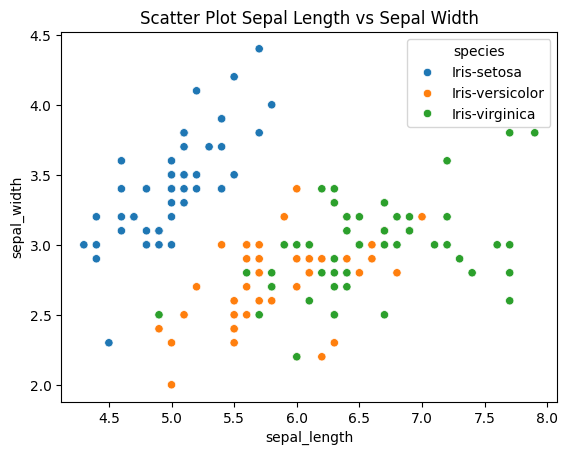

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    data=df,
    x="sepal_length",
    y="sepal_width",
    hue="species"
)

plt.title("Scatter Plot Sepal Length vs Sepal Width")
plt.show()

### Analisa Korelasi


In [22]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


### Statistik Deskriptif


In [23]:
import pandas as pd
from scipy import stats

df = pd.read_csv("IRIS.csv")

# Ambil hanya kolom numerik (tanpa species)
df_numeric = df.select_dtypes(include=['int64','float64'])

for col in df_numeric.columns:
    print("Statistik untuk", col,)
    print("Jumlah Data      :", df[col].count())
    print("Rata-rata        :", df[col].mean())
    print("Nilai Minimum    :", df[col].min())
    print("Q1               :", df[col].quantile(0.25))
    print("Median (Q2)      :", df[col].quantile(0.5))
    print("Q3               :", df[col].quantile(0.75))
    print("Nilai Maximum    :", df[col].max())
    print("Kemencengan      :", round(df[col].skew(), 6))

    mode = stats.mode(df[col], keepdims=True)
    print("Modus            :", mode.mode[0], "dengan jumlah", mode.count[0])

    print("Standar Deviasi  :", round(df[col].std(), 6))
    print("Variansi         :", round(df[col].var(), 6))
    print("\n")

Statistik untuk sepal_length
Jumlah Data      : 150
Rata-rata        : 5.843333333333334
Nilai Minimum    : 4.3
Q1               : 5.1
Median (Q2)      : 5.8
Q3               : 6.4
Nilai Maximum    : 7.9
Kemencengan      : 0.314911
Modus            : 5.0 dengan jumlah 10
Standar Deviasi  : 0.828066
Variansi         : 0.685694


Statistik untuk sepal_width
Jumlah Data      : 150
Rata-rata        : 3.0540000000000003
Nilai Minimum    : 2.0
Q1               : 2.8
Median (Q2)      : 3.0
Q3               : 3.3
Nilai Maximum    : 4.4
Kemencengan      : 0.334053
Modus            : 3.0 dengan jumlah 26
Standar Deviasi  : 0.433594
Variansi         : 0.188004


Statistik untuk petal_length
Jumlah Data      : 150
Rata-rata        : 3.758666666666666
Nilai Minimum    : 1.0
Q1               : 1.6
Median (Q2)      : 4.35
Q3               : 5.1
Nilai Maximum    : 6.9
Kemencengan      : -0.274464
Modus            : 1.5 dengan jumlah 14
Standar Deviasi  : 1.76442
Variansi         : 3.113179


Statistik

### Pengecekan Missing Value

Pada dataset ini tidak ditemukan data kosong, sehingga dataset iris flower ini dalam kondisi bersih dan bisa dilakukan pengecekan analisis lebih lanjut.

In [24]:
df.isnull().sum()


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Berdasarkan pengecekan missing value, tidak ditemukan data kosong pada dataset. Tetapi berdasarkan analisis menggunakan aplikasi orange, terdapat 15 data yang terindikasi sebagai outliers. **Outlier** merupakan data aneh dari dataset yang ada.

### Gambaran Statistik Awal

Untuk mengetahui karakteristik numerik dari masing-masing atribut,  maka dilakukan perhitungan statistik deskriptif menggunakan fungsi describe()

In [25]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Eksplorasi Iris menggunakan Orange


### Alur Analisis Data Menggunakan Orange
Pada tahap ini dilakukan eksplorasi data menggunakan beberapa widget pada Orange untuk memahami karakteristik dataset IRIS.

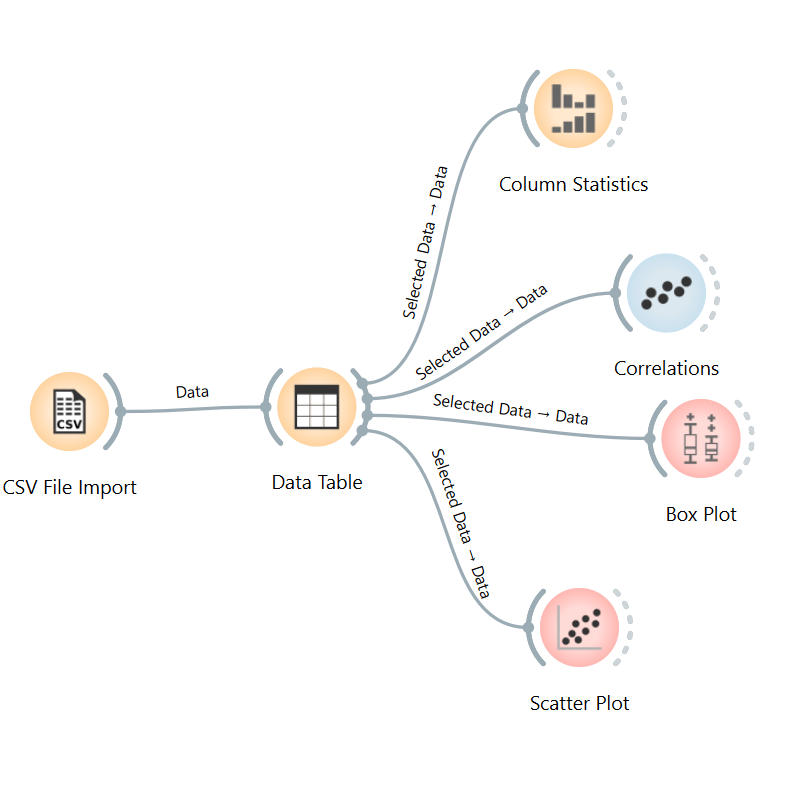

### File

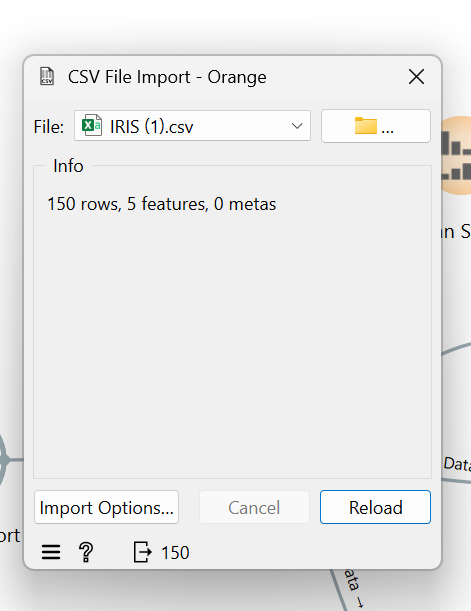

### Feature Statistics

**Widget Feature Statistics digunakan untuk menampilkan statistik deskriptif setiap fitur, seperti:**

- Rata-rata

- Minimum dan maksimum

- Distribusi data

- Widget ini membantu memahami karakteristik dasar setiap variabel.

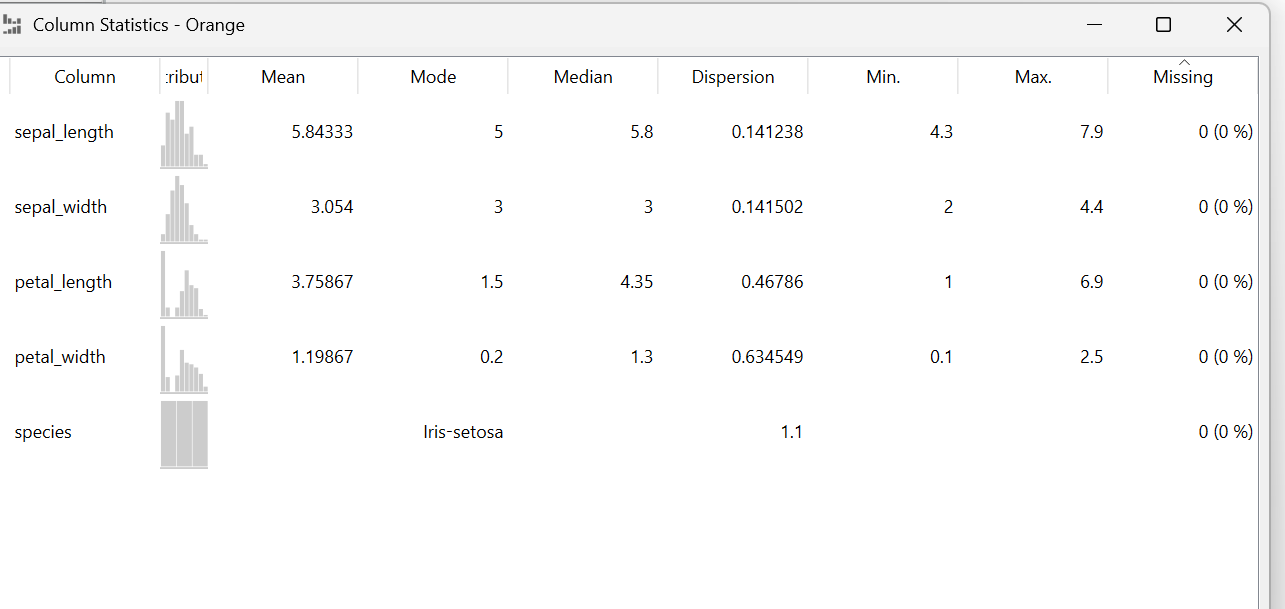

### Scatter Plot

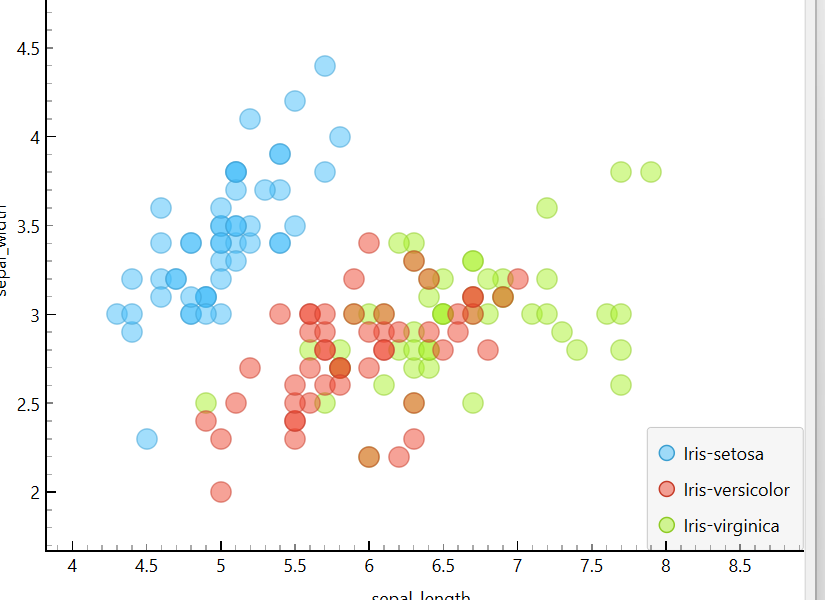

### Mean (Rata - Rata)

Mean atau rata-rata merupakan ukuran pemusatan data yang diperoleh dengan menjumlahkan seluruh nilai dalam suatu data kemudian dibagi dengan banyak data. Mean digunakan untuk mengetahui nilai tengah secara umum dari keseluruhan data.

Berikut rumus untuk menghitung mean secara umum:


$$
\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}
$$

Keterangan :

$
\begin{aligned}
\bar{x} &= \text{Mean (rata-rata)} \\
x_i &= \text{Nilai data ke-i} \\
n &= \text{Jumlah data} \\
\sum &= \text{Simbol penjumlahan}
\end{aligned}
$


Pada dataset Iris Flower, nilai mean digunakan untuk mengetahui rata-rata dari masing-masing atribut numerik seperti *sepal_length*, *sepal_width*, *petal_length*, dan *petal_width*.

### Median (Nilai Tengah)

Median merupakan ukuran pemusatan data yang menunjukkan nilai tengah dari suatu data setelah data diurutkan dari yang terkecil hingga terbesar. Median digunakan ketika ingin mengetahui nilai tengah yang tidak terlalu dipengaruhi oleh nilai ekstrem (outlier).

Jika jumlah data ganjil, maka median adalah nilai tepat di tengah.
Jika jumlah data genap, maka median adalah rata-rata dari dua nilai tengah.

**Median Untuk Data Tunggal**

Rumus Median Untuk $N$ Ganjil :

$$
Me = x_{\frac{N+1}{2}}
$$


Rumus Median Untuk $N$ Genap :

$$
Me = \frac{x_{\frac{N}{2}} + x_{\frac{N}{2}+1}}{2}
$$

Keterangan :

$
\begin{aligned}
Me &= \text{Median} \\
x &= \text{Data yang telah diurutkan} \\
N &= \text{Jumlah data}
\end{aligned}
$


**Median Untuk Data Berkelompok**

$$
Me = x_{ij} + \left( \frac{\frac{n}{2} - f_{kij}}{f_i} \right) p
$$

Keterangan :

$
\begin{aligned}
Me &= \text{Median} \\
x_{ij} &= \text{Batas bawah kelas median} \\
n &= \text{Jumlah data} \\
f_{kij} &= \text{Frekuensi kumulatif sebelum kelas median} \\
f_i &= \text{Frekuensi pada kelas median} \\
p &= \text{Panjang interval kelas}
\end{aligned}
$


Pada dataset Iris Flower, median digunakan untuk mengetahui nilai tengah dari masing-masing atribut numerik setelah data diurutkan, sehingga dapat memberikan gambaran pusat data yang lebih stabil dibandingkan mean ketika terdapat nilai ekstrem (outlier).

### Modus/Mode (Nilai Sering Muncul)

Modus adalah nilai yang paling sering muncul dalam suatu kumpulan data. Modus digunakan untuk mengetahui nilai yang memiliki frekuensi tertinggi dalam suatu distribusi data.

Pada data numerik, modus menunjukkan nilai yang paling banyak muncul. Sedangkan pada data kategorikal (seperti atribut species pada dataset Iris), modus menunjukkan kategori yang paling dominan.

Suatu data dapat memiliki:
- Satu modus (unimodal)
- Dua modus (bimodal)
- Lebih dari dua modus (multimodal)
- Atau tidak memiliki modus jika semua nilai muncul dengan frekuensi yang sama.


Rumus Modus data tunggal :

$$
Mo = \text{Nilai dengan frekuensi tertinggi}
$$


Pada data numerik unimodal yang cukup miring (asimetris), terdapat hubungan empiris antara mean, median, dan modus:

$$
\text{Mean} - \text{Modus} \approx 3(\text{Mean} - \text{Median})
$$

Ini menyiratkan bahwa mode untuk kurva frekuensi unimodal yang cukup miring dapat dengan mudah didekati jika nilai rata-rata dan median diketahui.



### Rentang (Range), Quartil, and Rentang Interquartile


#### Range
Rentang (Range) merupakan ukuran penyebaran data yang menunjukkan selisih antara nilai maksimum dan nilai minimum dalam suatu dataset. Rentang memberikan gambaran seberapa luas variasi data secara keseluruhan.

Rentang adalah selisih antara nilai terbesar (maks ()) dan terkecil (min ()).

$$
R = X_{max} - X_{min}
$$


Keterangan :

$
\begin{aligned}
R &= \text{Rentang (Range)} \\
X_{max} &= \text{Nilai maksimum} \\
X_{min} &= \text{Nilai minimum}
\end{aligned}
$

#### Kuartil (Quartile)

Kuartil adalah ukuran statistik yang membagi data yang telah diurutkan menjadi empat bagian yang sama besar. Kuartil digunakan untuk melihat distribusi dan penyebaran data secara lebih detail.

Terdapat tiga kuartil utama:
- Q1 (Kuartil 1 / Lower Quartile) → 25% data berada di bawah nilai ini
- Q2 (Kuartil 2 / Median) → 50% data berada di bawah nilai ini
- Q3 (Kuartil 3 / Upper Quartile) → 75% data berada di bawah nilai ini

#### Interkuartil (Interquartile)

Rentang Interkuartil (IQR) adalah ukuran penyebaran data yang menunjukkan selisih antara kuartil ketiga dan kuartil pertama. IQR menggambarkan penyebaran 50% data tengah dan sering digunakan untuk mendeteksi outlier.

Rumus Interquartile:

$$
IQR = Q_3 - Q_1
$$

Data dikatakan outlier jika :

$$
X < Q_1 - 1.5(IQR)
$$


$$atau$$


$$
X > Q_3 + 1.5(IQR)
$$

Pada dataset Iris Flower, rentang digunakan untuk mengetahui selisih nilai maksimum dan minimum dari setiap atribut numerik. Kuartil membantu memahami distribusi data dalam empat bagian, sedangkan IQR digunakan untuk mengukur penyebaran data tengah serta mendeteksi adanya outlier.

### Variansi dan Standar Deviasi

Variansi dan standar deviasi adalah ukuran penyebaran data yang menunjukkan sejauh mana nilai-nilai dalam dataset menyebar dari nilai rata-rata.
- Standar Deviasi yang rendah berarti bahwa pengamatan data cenderung sangat dekat dengan rata-rata
- Standar Deviasi yang tinggi menunjukkan data tersebar di sejumlah nilai-nilai besar.


#### Variansi
Untuk atribut numerik $X$ dengan $N$ pengamatan $x_1, x_2,...,x_N,$ variansi populasi $(𝜎^2)$ dirumuskan sebagai berikut :

$$
\sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x})^2 = \left( \frac{1}{N} \sum_{i=1}^{N} x_i^2 \right) - \bar{x}^2
$$



#### Standar Deviasi
Standar deviasi $(𝜎)$ adalah akar kuadrat dari variansi.
Sifat dasar dari standar deviasi sebagai ukuran penyebaran data adalah sebagai berikut:

- Ukuran $σ$ mengeukur sebaran disekitar rata-rata dan harus dipertimbangkan bila rata-rata dipilih sebagai ukuran pusat data
- $σ = 0$ hanya jika tidak ada penyebaran data, hanya terjadi ketika semua pengamatan memiliki nilai sama, Jika tidak maka $σ > 0$.



Pada dataset Iris Flower, variansi dan standar deviasi digunakan untuk mengukur sebaran nilai pada atribut numerik (sepal_length, sepal_width, petal_length, petal_width). Nilai standar deviasi yang rendah menunjukkan bahwa data terkonsentrasi di sekitar mean, sedangkan nilai tinggi menunjukkan variasi data yang lebih besar.

#### Skewness (Kemencengan)
Skewness (kemencengan) adalah ukuran derajat distorsi dari distribusi data dibandingkan dengan kurva normal simetris. Skewness digunakan untuk mengetahui apakah distribusi data miring ke kanan, ke kiri, atau simetris.

- Skewness = 0 → distribusi simetris (normal)
- Skewness > 0 → distribusi miring ke kanan (ekor di kanan lebih panjang)
- Skewness < 0 → distribusi miring ke kiri (ekor di kiri lebih panjang)

Untuk menghitung derajat distorisi dapat menggunakan Koefisien Kemencengan Pearson yang diperoleh dengan menggunakan nilai selisih rata-rata dengan modus dibagi simpangan baku. Koefisien Kemencengan Pearson dirumuskan sebagai berikut

$$
sk = \frac{\bar{X} - Mo}{s}
$$

dengan


$$
\bar{X} - Mo \approx 3 (\bar{X} - Me)
$$

maka

$$
sk \approx \frac{3(\bar{X} - Me)}{s}
$$

$
\text{Keterangan:} \\
\begin{aligned}
sk & = \text{Koefisien kemencengan (skewness)} \\
\bar{X} & = \text{Mean (rata-rata)} \\
Me & = \text{Median (nilai tengah)} \\
Mo & = \text{Modus (nilai paling sering muncul)} \\
s & = \text{Standar deviasi} \\
\bar{X} - Mo & \approx 3 (\bar{X} - Me) \quad \text{(hubungan empiris Pearson)}
\end{aligned}
$

# Mengukur Jarak dengan Tipe Data Campuran


## Pengertian Data Campuran?

Data campuran adalah data yang memiliki lebih dari satu tipe atribut, misalnya:

- **Numerik** → panjang, berat, umur  
- **Kategorikal** → warna, jenis, kelas  
- **Ordinal** → rendah, sedang, tinggi  

### Contoh Data Campuran

| Panjang | Warna | Jenis |
|--------|-------|-------|
| 5.1 | Merah | A |
| 4.9 | Biru | B |

### Permasalahan
Jarak **Euclidean biasa tidak bisa langsung digunakan**, karena:
- Data kategorikal tidak bisa dikurangkan
- Skala antar atribut berbeda


## Metode Mengukur Jarak Data Campuran

### Gower Distance
- Dapat menangani **numerik + kategorikal + ordinal**
- Setiap atribut dinormalisasi (0–1)
- Jarak akhir adalah rata-rata jarak tiap atribut

**Rumus:**
$$
D(i,j) = \frac{1}{p} \sum_{k=1}^{p} d_{ijk}
$$

ini cocok untuk **clustering** dan **similarity analysis** pada data campuran.



### Encoding + Euclidean
- Data kategorikal diubah menjadi numerik (One-Hot Encoding)
- Jarak dihitung dengan Euclidean / Manhattan
- Kurang ideal karena bisa menimbulkan **bias dimensi**



## Kesimpulan
- Data campuran → **Gower Distance paling direkomendasikan**
- Data numerik saja → **Euclidean / Manhattan**



## Analisis Data Campuran Menggunakan Orange Data Mining

**Orange Data Mining** adalah tools visual data mining berbasis *drag-and-drop* yang mendukung:
- Data numerik & kategorikal
- Perhitungan jarak (distance)
- Clustering & visualisasi

### Tata Caranya di Orange
1. **File** → Load dataset
2. **Edit Domain** → Atur tipe atribut (numeric / categorical)
3. **Distances** → Hitung jarak (Euclidean / Manhattan / Cosine)
4. **Clustering / Visualization** → Analisis hasil


# Analisis Jarak Data Campuran pada Dataset Iris


## Implementasi Khusus Dataset Iris

Dataset **Iris Flower** berisi data pengukuran bunga Iris dengan struktur sebagai berikut:

| Atribut | Tipe |
|-------|------|
| SepalLengthCm | Numerik |
| SepalWidthCm | Numerik |
| PetalLengthCm | Numerik |
| PetalWidthCm | Numerik |
| Species | Kategorikal |

Dataset ini disebut **data campuran** karena:
- Fitur pengukuran bersifat **numerik**
- Label kelas (**Species**) bersifat **kategorikal**

Tujuan pengukuran jarak pada dataset Iris adalah untuk:
- Mengetahui tingkat kemiripan antar bunga
- Mendukung proses clustering dan visualisasi



## Implementasi Jarak Dataset Iris Menggunakan Orange Data Mining

### Langkah-langkah di Orange

**1. File**
- Masukkan file `IRIS.csv`
- Dataset akan terbaca sebagai tabel data

**2. Edit Domain**
- Pastikan atribut:
  - Sepal & Petal → Numeric
  - Species → Categorical (Class)

*(Screenshot: Tampilan Edit Domain dengan Species sebagai Class)*
### 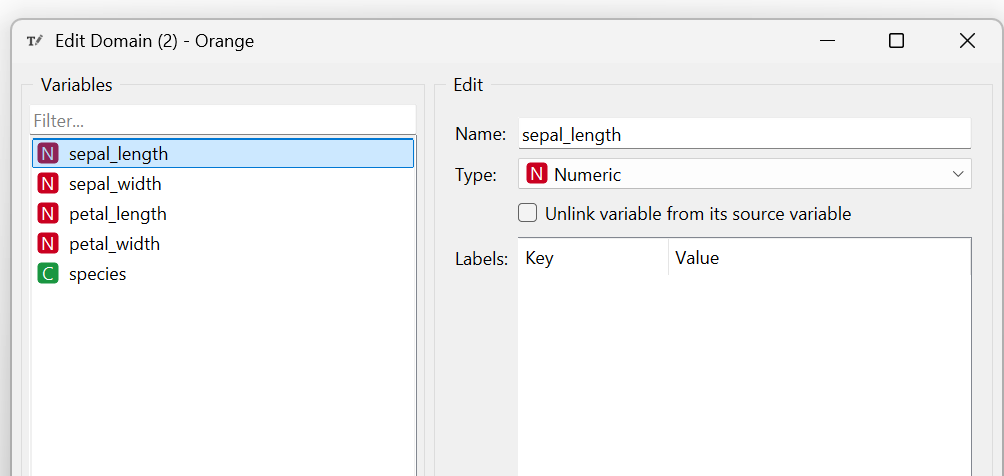

**3. Distances**
- Pilih metode jarak:
  - Euclidean (default untuk data numerik)
  - Manhattan (alternatif)
- Orange akan menghitung matriks jarak antar data

*(Screenshot: Widget Distances menunjukkan Distance Matrix)*

### 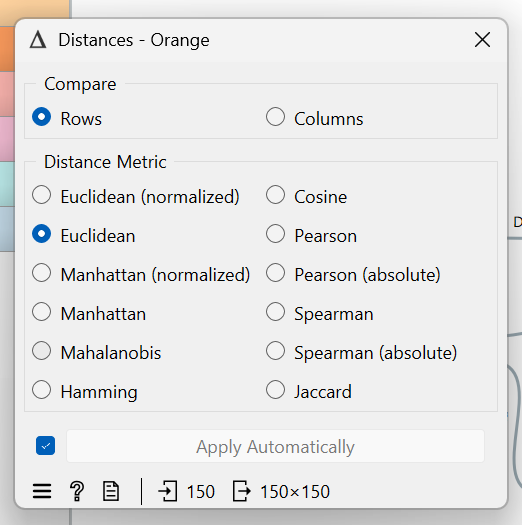 
### 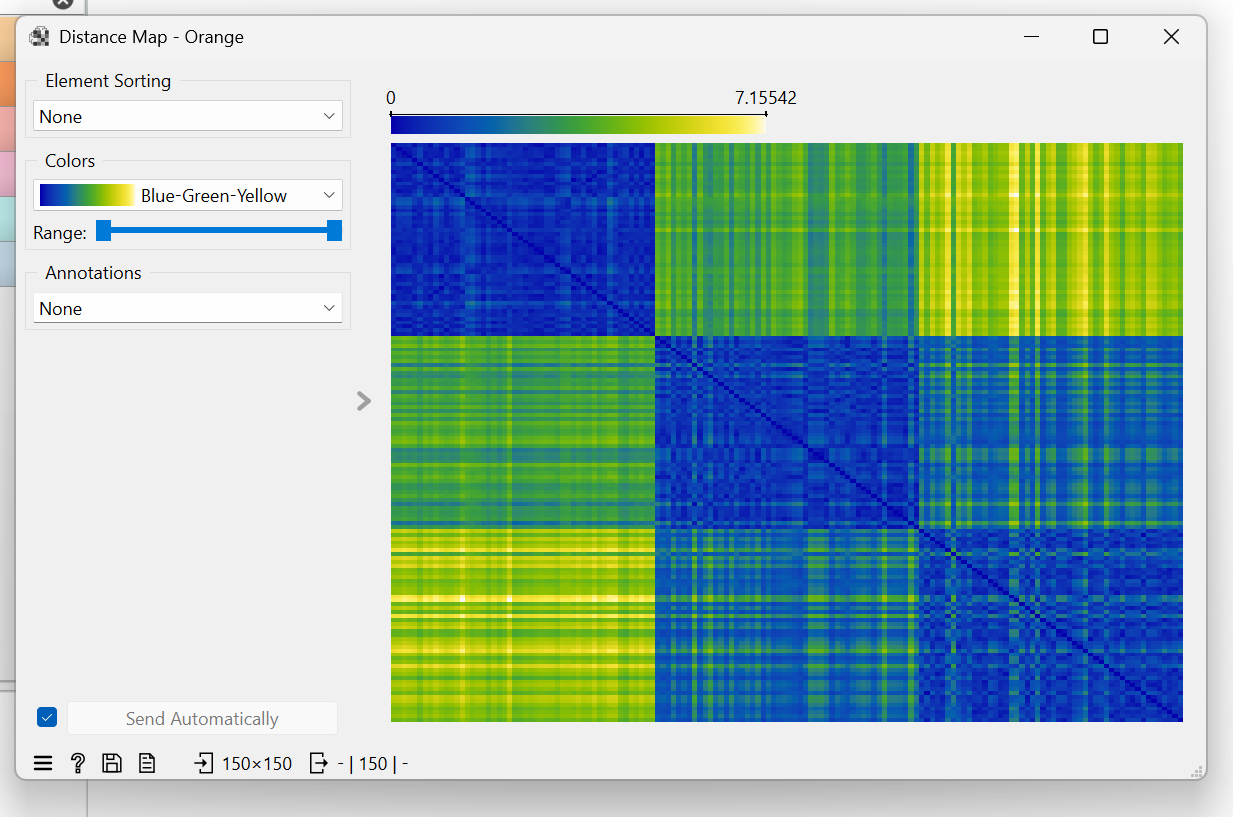

**4. Visualisasi**
  ### Scatter Plot
  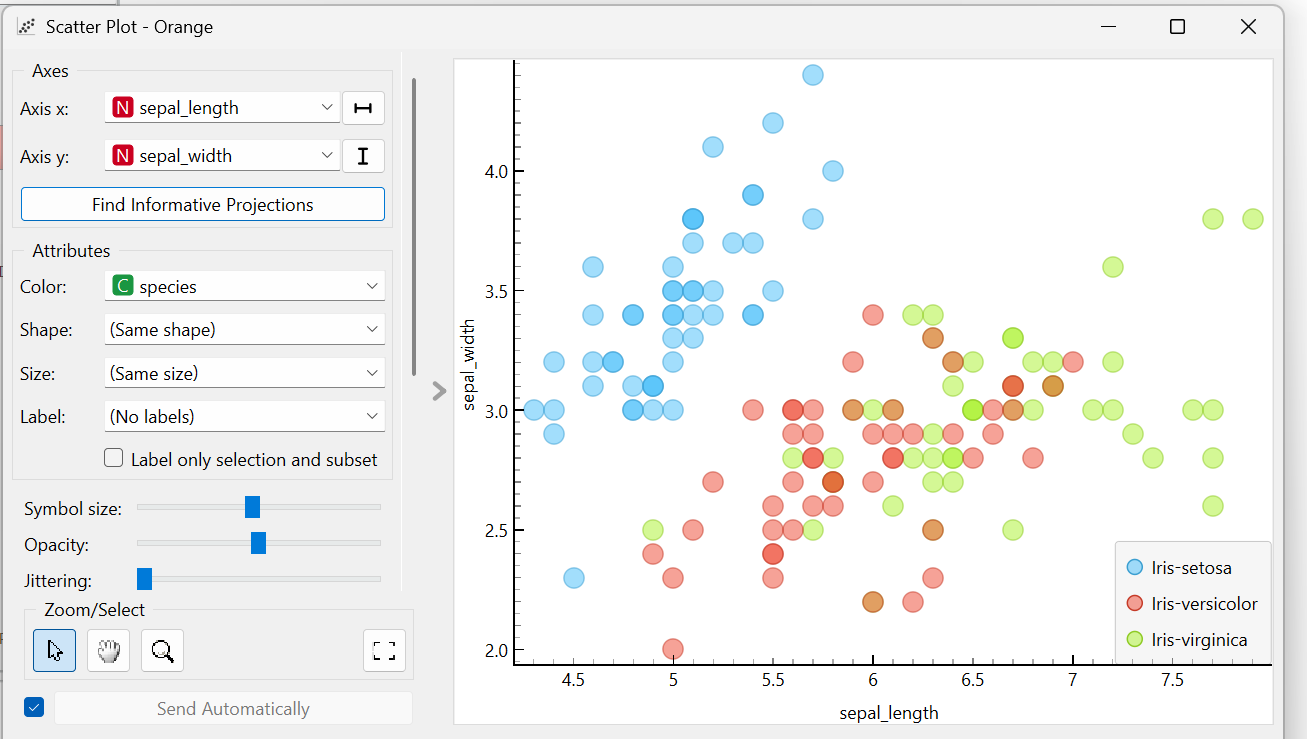

  ### Hierarchical Clustering
  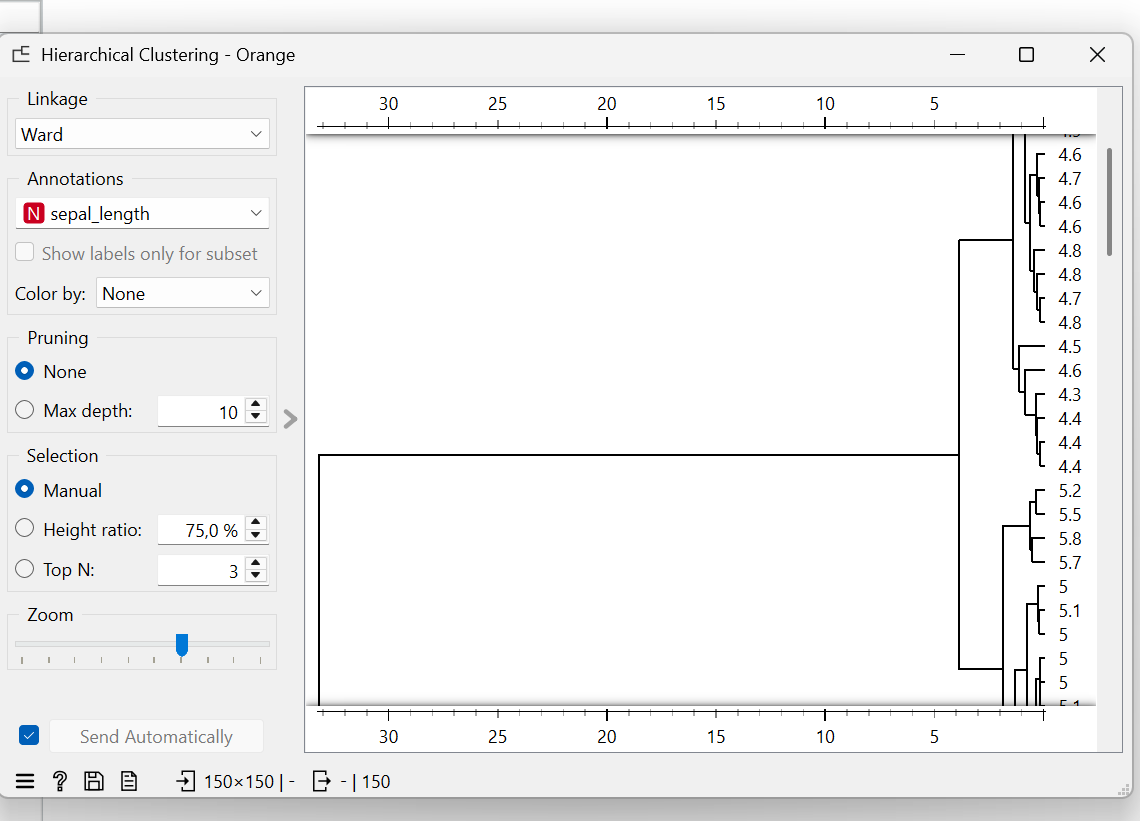
  
  ### Distance Map
  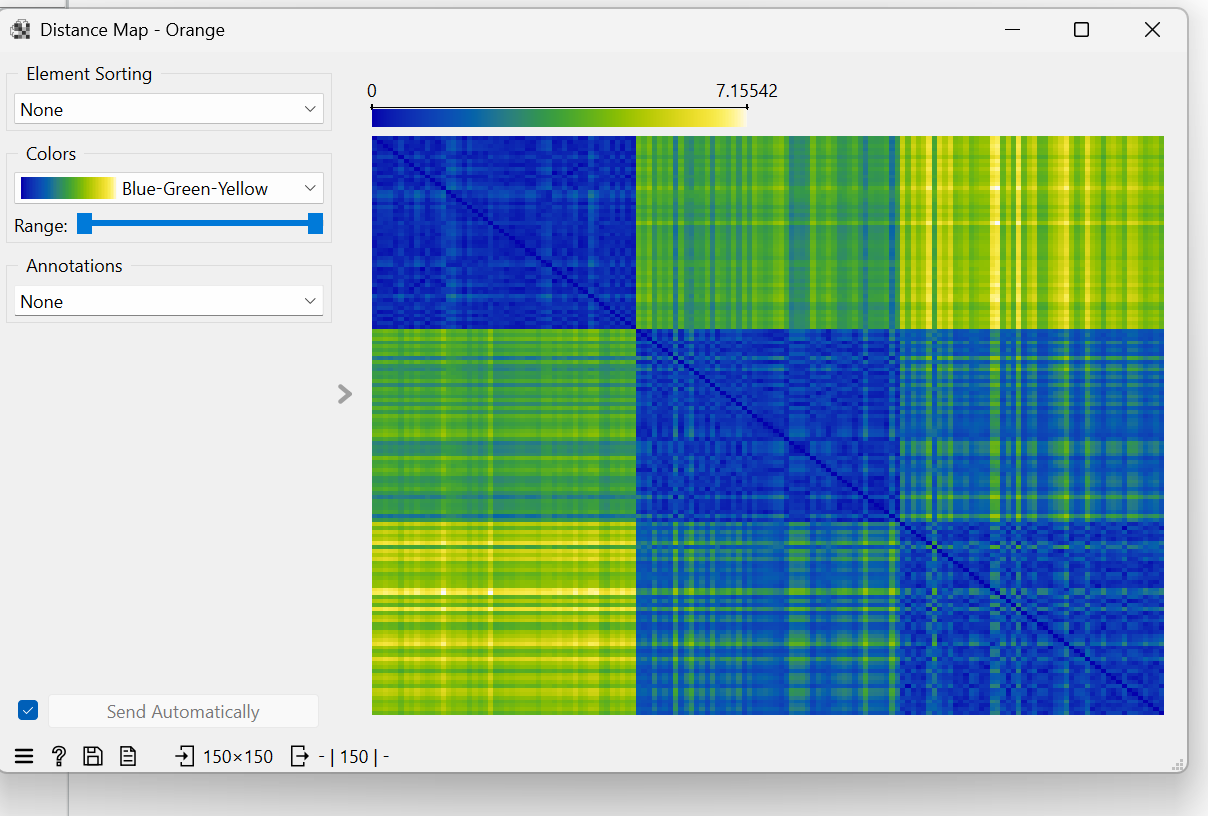




## Contoh Perhitungan Gower Distance (Python)

Berikut contoh sederhana menghitung **Gower Distance** pada dataset Iris menggunakan Python.


In [6]:
import pandas as pd
import numpy as np

# 1. Load dataset
df = pd.read_csv("IRIS.csv")
print("Dataset berhasil dimuat!")

# 2. SESUAIKAN NAMA KOLOM DISINI (Harus sama persis dengan printout tadi)
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
categorical_cols = ['species']

# 3. Normalisasi data numerik (0–1)
df_norm = df.copy()
for col in numeric_cols:
    # Gunakan .min() (bukan mim)
    min_val = df[col].min()
    max_val = df[col].max()
    
    if max_val - min_val != 0:
        df_norm[col] = (df[col] - min_val) / (max_val - min_val)
    else:
        df_norm[col] = 0

# 4. Fungsi Gower Distance
def gower_distance(row1, row2):
    # Bagian Numerik
    v1_num = row1[numeric_cols].to_numpy(dtype=float)
    v2_num = row2[numeric_cols].to_numpy(dtype=float)
    d_num = np.abs(v1_num - v2_num).mean()
    
    # Bagian Kategorikal
    v1_cat = row1[categorical_cols].to_numpy()
    v2_cat = row2[categorical_cols].to_numpy()
    d_cat = np.mean(v1_cat != v2_cat)
    
    return (d_num + d_cat) / 2

# 5. Cek Hasil
distance = gower_distance(df_norm.iloc[0], df_norm.iloc[1])
print(f"Jarak Gower antara baris 0 dan 1 adalah: {distance:.4f}")

Dataset berhasil dimuat!
Jarak Gower antara baris 0 dan 1 adalah: 0.0330
